# Write a Python Program to demonstrate feature extraction and t-SNE Visualization

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.manifold import TSNE
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tqdm import tqdm

In [11]:
dataset_path = "./inputs/caltech-101"

selected_classes = ["accordion", "anchor", "ant", "barrel"]

base_model = ResNet50(weights="imagenet", include_top=False, pooling="avg")
model = Model(inputs=base_model.input, outputs=base_model.output)

In [12]:
def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    return (model.predict(img_array, verbose=0)).flatten()

In [13]:
features, labels = [], []

for category in os.listdir(dataset_path):
    if category not in selected_classes:
        continue

    category_path = os.path.join(dataset_path, category)

    for img_name in tqdm(os.listdir(category_path)):
        img_path = os.path.join(category_path, img_name)

        try:
            img_feat = extract_features(img_path)
            features.append(img_feat)
            labels.append(category)
        except:
            pass

100%|██████████| 47/47 [00:04<00:00, 10.33it/s]


In [14]:
features = np.array(features)
print("Total image processed:", len(features))

Total image processed: 186


In [19]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

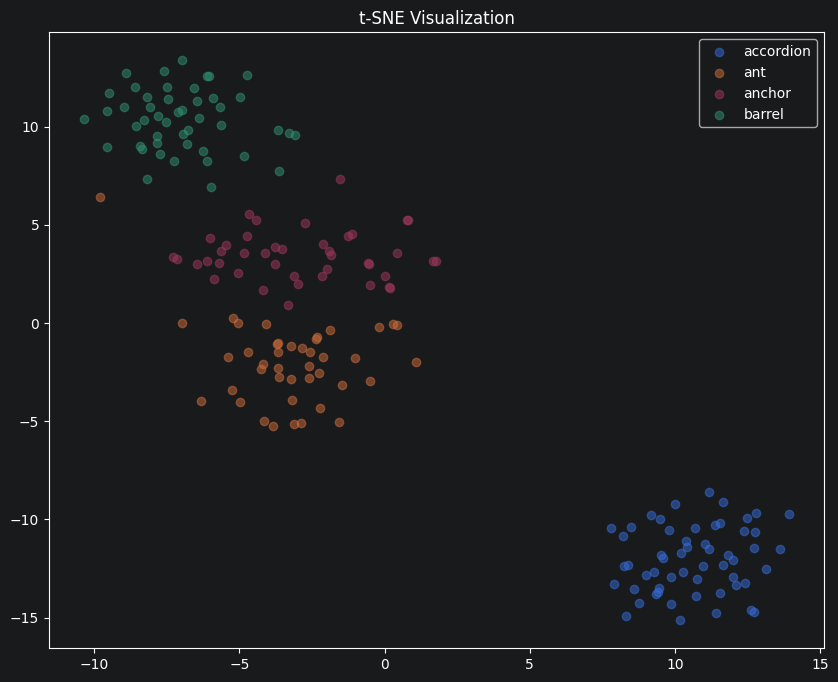

In [20]:
features_2D = tsne.fit_transform(features)
plt.figure(figsize=(10, 8))
unique_labels = list(set(labels))

for label in unique_labels:
    indices = [i for i in range(len(labels)) if labels[i] == label]
    plt.scatter(features_2D[indices, 0], features_2D[indices, 1], label=label, alpha=0.5)

plt.title("t-SNE Visualization")
plt.legend()
plt.show()